In [2]:
import torch
from torch import nn
from torch.optim import Adam
from torchvision.transforms import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
                      

cuda


In [4]:
image_path = []
labels = []

for i in os.listdir("afhq"): # - > train , val
    for label in os.listdir(f"afhq/{i}"): # -> cat, dog, wild
        for image in os.listdir(f"afhq/{i}/{label}"): # -> images
            image_path.append(f"afhq/{i}/{label}/{image}")
            labels.append(label)
            
data_df = pd.DataFrame(zip(image_path, labels), columns = ("image_path","labels"))


In [5]:
data_df.head()

,image_path,labels
0,afhq/train/cat/flickr_cat_000002.jpg,cat
1,afhq/train/cat/flickr_cat_000003.jpg,cat
2,afhq/train/cat/flickr_cat_000004.jpg,cat
3,afhq/train/cat/flickr_cat_000005.jpg,cat
4,afhq/train/cat/flickr_cat_000006.jpg,cat


In [6]:
train = data_df.sample(frac = 0.7)
test = data_df.drop(train.index)
val = test.sample(frac = 0.5)
test = test.drop(val.index)

print(train.shape,test.shape,val.shape)

(11291, 2) (2419, 2) (2420, 2)


In [7]:
label_encoder = LabelEncoder()
label_encoder.fit(data_df["labels"]) # -> learning encoding from whole dataframe labels

transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(), # converts the image into pixel matrix and also scale between 0-1
    transforms.ConvertImageDtype(torch.float)
])

In [8]:
class CustomImageDataset(Dataset):
    def __init__(self,dataframe,transform = None):
        self.dataframe = dataframe
        self.transform = transform
        self.labels = torch.tensor(label_encoder.transform(dataframe["labels"]),dtype=torch.long) # -> applying the encoding on the passed dataframe
    def __len__(self):
        return len(self.dataframe) # or self.dataframe.shape[0]
    def __getitem__(self,index):
        img_path = self.dataframe.iloc[index,0]
        label = self.labels[index]

        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label
            
        
                                        
        

In [9]:
label_encoder.transform(["wild","cat","dog"])

array([2, 0, 1])

In [10]:
train_dataset = CustomImageDataset(dataframe = train, transform = transform)
test_dataset = CustomImageDataset(dataframe = test, transform = transform)
val_dataset = CustomImageDataset(dataframe = val, transform = transform)

In [11]:
train_dataset.__getitem__(2)

(tensor([[[0.9490, 0.9490, 0.9529,  ..., 0.9882, 0.9882, 0.9882],
          [0.9490, 0.9490, 0.9529,  ..., 0.9882, 0.9882, 0.9882],
          [0.9490, 0.9490, 0.9529,  ..., 0.9922, 0.9882, 0.9882],
          ...,
          [0.5843, 0.5725, 0.5569,  ..., 0.8549, 0.8118, 0.7725],
          [0.6235, 0.6118, 0.5882,  ..., 0.8275, 0.8314, 0.7882],
          [0.6039, 0.6000, 0.6196,  ..., 0.7882, 0.7804, 0.7647]],
 
         [[0.9255, 0.9255, 0.9294,  ..., 0.9804, 0.9804, 0.9804],
          [0.9255, 0.9255, 0.9294,  ..., 0.9804, 0.9804, 0.9804],
          [0.9255, 0.9255, 0.9294,  ..., 0.9843, 0.9804, 0.9804],
          ...,
          [0.4745, 0.4627, 0.4471,  ..., 0.8039, 0.7608, 0.7216],
          [0.5137, 0.5020, 0.4784,  ..., 0.7765, 0.7804, 0.7373],
          [0.4941, 0.4902, 0.5098,  ..., 0.7373, 0.7294, 0.7137]],
 
         [[0.9725, 0.9725, 0.9765,  ..., 0.9922, 0.9922, 0.9922],
          [0.9725, 0.9725, 0.9765,  ..., 0.9922, 0.9922, 0.9922],
          [0.9725, 0.9725, 0.9765,  ...,

In [12]:
label_encoder.inverse_transform([2])

array(['wild'], dtype=object)

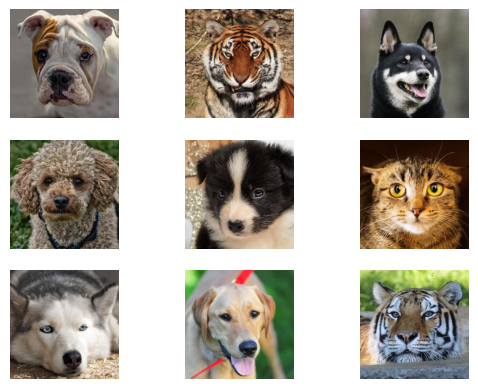

In [13]:
n_rows = 3
n_cols = 3

f, axarr = plt.subplots(n_rows,n_cols)
for row in range(n_rows):
    for col in range(n_cols):
        image = Image.open(data_df.sample(n = 1)["image_path"].iloc[0]).convert("RGB")
        axarr[row,col].imshow(image)
        axarr[row,col].axis("off")
plt.show()                                                                           

In [14]:
LR = 1e-4
BATCH_SIZE = 32
EPOCHS = 10


In [15]:
train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = BATCH_SIZE, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = BATCH_SIZE, shuffle = True)

In [16]:
class MyModel(nn.Module):
    def __init__(self):
        super(MyModel,self).__init__()

        self.conv1 = nn.Conv2d(3,32, kernel_size = 3,padding = 1) # (input_channel, output/no. of filters, kernel_size)
        self.conv2 = nn.Conv2d(32, 64, kernel_size = 3,padding = 1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size = 3,padding = 1)

        self.pooling = nn.MaxPool2d(2,2)

        self.relu = nn.ReLU()

        self.flatten = nn.Flatten()
        self.linear = nn.Linear((128*16*16),128)

        self.output = nn.Linear(128, len(data_df['labels'].unique()))

    def forward(self,x):
        x = self.conv1(x) # outputs - > (32,128,128) = (no. of filters, (size))
        x = self.pooling(x) # output - > (32,64,64)
        x = self.relu(x)

        x = self.conv2(x) # outputs - > (64,64,64) = (no. of filters, (size))
        x = self.pooling(x) # output - > (64,32,32)
        x = self.relu(x)

        x = self.conv3(x) # outputs - > (128,32,32) = (no. of filters, (size))
        x = self.pooling(x) # output - > (128,16,16)
        x = self.relu(x)

        x = self.flatten(x)
        x = self.linear(x)
        x = self.output(x)
        return x

In [17]:
model = MyModel().to(device)

In [18]:
from torchsummary import summary
summary(model, input_size = (3,128,128))

Layer (type:depth-idx)                   Param #
├─Conv2d: 1-1                            896
├─Conv2d: 1-2                            18,496
├─Conv2d: 1-3                            73,856
├─MaxPool2d: 1-4                         --
├─ReLU: 1-5                              --
├─Flatten: 1-6                           --
├─Linear: 1-7                            4,194,432
├─Linear: 1-8                            387
Total params: 4,288,067
Trainable params: 4,288,067
Non-trainable params: 0


Layer (type:depth-idx)                   Param #
├─Conv2d: 1-1                            896
├─Conv2d: 1-2                            18,496
├─Conv2d: 1-3                            73,856
├─MaxPool2d: 1-4                         --
├─ReLU: 1-5                              --
├─Flatten: 1-6                           --
├─Linear: 1-7                            4,194,432
├─Linear: 1-8                            387
Total params: 4,288,067
Trainable params: 4,288,067
Non-trainable params: 0

In [19]:
from torchinfo import summary
summary(model, input_size=(1, 3, 128, 128))

Layer (type:depth-idx)                   Output Shape              Param #
MyModel                                  [1, 3]                    --
├─Conv2d: 1-1                            [1, 32, 128, 128]         896
├─MaxPool2d: 1-2                         [1, 32, 64, 64]           --
├─ReLU: 1-3                              [1, 32, 64, 64]           --
├─Conv2d: 1-4                            [1, 64, 64, 64]           18,496
├─MaxPool2d: 1-5                         [1, 64, 32, 32]           --
├─ReLU: 1-6                              [1, 64, 32, 32]           --
├─Conv2d: 1-7                            [1, 128, 32, 32]          73,856
├─MaxPool2d: 1-8                         [1, 128, 16, 16]          --
├─ReLU: 1-9                              [1, 128, 16, 16]          --
├─Flatten: 1-10                          [1, 32768]                --
├─Linear: 1-11                           [1, 128]                  4,194,432
├─Linear: 1-12                           [1, 3]                    38

In [20]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(),lr = LR)

In [21]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

In [107]:
epochs = 10
for epoch in range(epochs):
    total_acc_train = 0
    total_loss_train = 0
    total_acc_val = 0
    total_loss_val = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)  # Move batch to GPU
        labels = labels.to(device)  # Move batch to GPU
    
        optimizer.zero_grad()
        outputs = model(inputs)
        train_loss = criterion(outputs, labels)
        total_loss_train += train_loss.item()

        train_loss.backward()
        train_acc = (torch.argmax(outputs,axis = 1) == labels).sum().item()
        total_acc_train += train_acc
        optimizer.step()

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            val_loss = criterion(outputs,labels)
            total_loss_val += val_loss.item()

            val_acc = (torch.argmax(outputs,axis = 1) == labels).sum().item()
            total_acc_val += val_acc

    total_loss_train_plot.append(round(total_loss_train/1000,4))
    total_loss_validation_plot.append(round(total_loss_val/1000,4))
    
    total_acc_train_plot.append(round((total_acc_train/ train_dataset.__len__())*100,4))
    total_loss_validation_plot.append(round((total_acc_val/ val_dataset.__len__())*100,4))

    print(f'''Epoch no. {epoch + 1} Train Loss : {round(total_loss_train/1000, 4)} Train Accuracy {round(total_acc_train/train_dataset.__len__() * 100,4)}
              Validation Loss: {round(total_loss_val/1000,4)} Validation Accuracy : {round(total_acc_val/val_dataset.__len__() * 100,4)}''')
    
    print("="*25)
            
    
        
        
        

Epoch no. 1 Train Loss : 0.2143 Train Accuracy 73.6693
              Validation Loss: 0.0247 Validation Accuracy : 88.5124
Epoch no. 2 Train Loss : 0.0948 Train Accuracy 90.0275
              Validation Loss: 0.015 Validation Accuracy : 92.9752
Epoch no. 3 Train Loss : 0.0642 Train Accuracy 93.3753
              Validation Loss: 0.0123 Validation Accuracy : 94.0496
Epoch no. 4 Train Loss : 0.0474 Train Accuracy 95.1997
              Validation Loss: 0.0101 Validation Accuracy : 95.3306
Epoch no. 5 Train Loss : 0.0369 Train Accuracy 96.2005
              Validation Loss: 0.0084 Validation Accuracy : 95.9504
Epoch no. 6 Train Loss : 0.0286 Train Accuracy 97.2456
              Validation Loss: 0.008 Validation Accuracy : 96.1157
Epoch no. 7 Train Loss : 0.0219 Train Accuracy 97.777
              Validation Loss: 0.0083 Validation Accuracy : 96.0331
Epoch no. 8 Train Loss : 0.0185 Train Accuracy 98.335
              Validation Loss: 0.0089 Validation Accuracy : 95.9091
Epoch no. 9 Train Lo

In [26]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0
  for inputs, labels in test_loader:
      inputs = inputs.to(device)
      labels = labels.to(device)
      predictions = model(inputs)
      acc = (torch.argmax(predictions, axis = 1) == labels).sum().item()
      total_acc_test += acc
      test_loss = criterion(predictions, labels)
      total_loss_test += test_loss.item()

print(f"Accuracy Score is: {round((total_acc_test/test_dataset.__len__()) * 100, 4)} and Loss is {round(total_loss_test/1000, 4)}")

Accuracy Score is: 96.1554 and Loss is 0.0092


In [22]:
import torch
from torch.utils.data import DataLoader

def run_fast_training(model, optimizer, criterion, train_dataset, val_dataset, device, epochs=10):
    # 1. Clear metric collection lists
    total_loss_train_plot = []
    total_loss_validation_plot = []
    total_acc_train_plot = []
    total_acc_validation_plot = []

    # 2. Configure parallelized data pipeline configuration
    # 🟢 num_workers=2 forks processing tasks into background CPU threads
    # 🟢 pin_memory=True pipes CPU memory arrays straight to your RTX 3050 VRAM instantly
    train_loader = DataLoader(
        train_dataset, 
        batch_size=32, 
        shuffle=True, 
        num_workers=0, 
        pin_memory=True
    )
    
    val_loader = DataLoader(
        val_dataset, 
        batch_size=32, 
        shuffle=False, 
        num_workers=0, 
        pin_memory=True
    )

    print("🚀 Training started using accelerated pipeline parameters...")

    for epoch in range(epochs):
        total_acc_train = 0
        total_loss_train = 0
        total_acc_val = 0
        total_loss_val = 0

        # --- Training Execution Segment ---
        model.train()
        for inputs, labels in train_loader:
            inputs = inputs.to(device, non_blocking=True) # 🟢 non_blocking optimizes pin_memory transfer
            labels = labels.to(device, non_blocking=True)
        
            optimizer.zero_grad()
            outputs = model(inputs)
            train_loss = criterion(outputs, labels)
            total_loss_train += train_loss.item()

            train_loss.backward()
            train_acc = (torch.argmax(outputs, axis=1) == labels).sum().item()
            total_acc_train += train_acc
            optimizer.step()

        # --- Validation Execution Segment ---
        model.eval()
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                outputs = model(inputs)
                val_loss = criterion(outputs, labels)
                total_loss_val += val_loss.item()

                val_acc = (torch.argmax(outputs, axis=1) == labels).sum().item()
                total_acc_val += val_acc

        # Compute metric aggregates
        total_loss_train_plot.append(round(total_loss_train / len(train_loader), 4))
        total_loss_validation_plot.append(round(total_loss_val / len(val_loader), 4))
        total_acc_train_plot.append(round((total_acc_train / len(train_dataset)) * 100, 4))
        total_acc_validation_plot.append(round((total_acc_val / len(val_dataset)) * 100, 4))

        print(f"Epoch no. {epoch + 1} "
              f"Train Loss: {total_loss_train_plot[-1]} | Train Acc: {total_acc_train_plot[-1]}%\n"
              f"             Val Loss: {total_loss_validation_plot[-1]} | Val Acc: {total_acc_validation_plot[-1]}%")
        print("=" * 25)

    return total_loss_train_plot, total_loss_validation_plot, total_acc_train_plot, total_acc_validation_plot


# 🟢 MANDATORY SAFE GUARD CLAUSE FOR WINDOWS RECURSION MANAGEMENT
if __name__ == '__main__':
    # Call your pipeline function here
    train_loss_hist, val_loss_hist, train_acc_hist, val_acc_hist = run_fast_training(
        model=model,
        optimizer=optimizer,
        criterion=criterion,
        train_dataset=train_dataset, # Pass your training dataset variable name
        val_dataset=val_dataset,     # Pass your validation dataset variable name
        device=device,
        epochs=10
    )


🚀 Training started using accelerated pipeline parameters...
Epoch no. 1 Train Loss: 0.5462 | Train Acc: 76.5123%
             Val Loss: 0.297 | Val Acc: 88.719%
Epoch no. 2 Train Loss: 0.2532 | Train Acc: 90.9043%
             Val Loss: 0.2246 | Val Acc: 91.9008%
Epoch no. 3 Train Loss: 0.1754 | Train Acc: 93.7738%
             Val Loss: 0.1607 | Val Acc: 94.3802%
Epoch no. 4 Train Loss: 0.1254 | Train Acc: 95.5983%
             Val Loss: 0.1454 | Val Acc: 94.6281%
Epoch no. 5 Train Loss: 0.0881 | Train Acc: 96.8028%
             Val Loss: 0.1347 | Val Acc: 94.9174%
Epoch no. 6 Train Loss: 0.0695 | Train Acc: 97.6441%
             Val Loss: 0.134 | Val Acc: 95.0826%
Epoch no. 7 Train Loss: 0.0574 | Train Acc: 98.025%
             Val Loss: 0.1655 | Val Acc: 94.7107%
Epoch no. 8 Train Loss: 0.0444 | Train Acc: 98.6007%
             Val Loss: 0.1282 | Val Acc: 95.7438%
Epoch no. 9 Train Loss: 0.031 | Train Acc: 99.0258%
             Val Loss: 0.1416 | Val Acc: 95.3719%
Epoch no. 10 Train

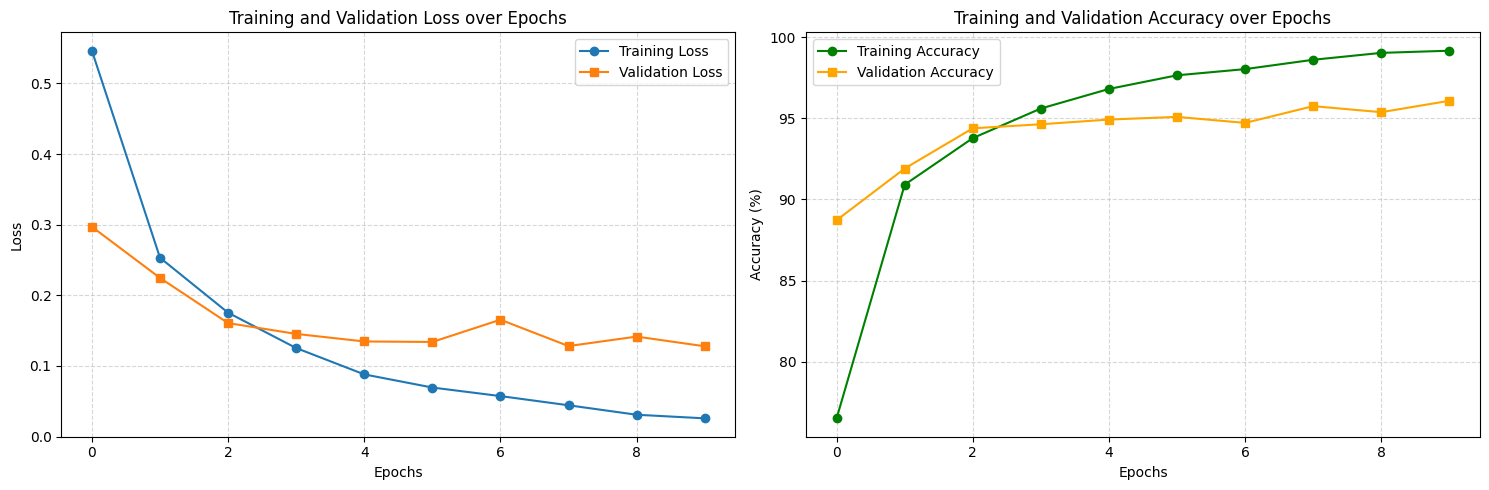

In [25]:
# Create the 1x2 plotting layout
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

# Left subplot: Loss tracking (using the newly returned function histories)
axs[0].plot(train_loss_hist, label='Training Loss', marker='o')
axs[0].plot(val_loss_hist, label='Validation Loss', marker='s')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[0].grid(True, linestyle='--', alpha=0.5)

# Right subplot: Accuracy tracking (using the newly returned function histories)
axs[1].plot(train_acc_hist, label='Training Accuracy', marker='o', color='green')
axs[1].plot(val_acc_hist, label='Validation Accuracy', marker='s', color='orange')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy (%)')
axs[1].legend()
axs[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()